In [1]:
import sys
sys.version

'3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]'

In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU available:", tf.config.list_physical_devices('GPU'))

C:\Users\becky\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0
Built with CUDA: False
GPU available: []


In [3]:
!nvidia-smi

Thu Mar  5 07:44:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.97                 Driver Version: 555.97         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   50C    P8              3W /   50W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Tue_Jun_13_19:42:34_Pacific_Daylight_Time_2023
Cuda compilation tools, release 12.2, V12.2.91
Build cuda_12.2.r12.2/compiler.32965470_0


## DSM150 Neural Networks: 

Final coursework assignment

Design, implement, and evaluate a deep learning 
model using cats and dogs dataset in Tensorflow

### Step 1: Define the problem and assemble the dataset

#### Definition of the problem:

The Dogs vs Cats dataset, available on TensorFlow Datasets, includes 23,262 training examples. The images are labeled with two classes: 0 for cats and 1 for dogs. The dataset is available at https://www.kaggle.com/c/dogs-vs-cats/data

The problem statement: predict the correct category of animal (either dog or cat) correctly.

The objective: minimize the classification error on unseen test images.

Coding inspired by University of London lectures and other online examples of the cats and dogs dataset, such as:

https://www.tensorflow.org/tutorials/keras/classification

In [3]:
# Import the libraries
import os
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import random
import seaborn as sns

from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras import regularizers

# import hidden layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, BatchNormalization

# Adam optimizer: has a better learning rate and reduced loss
from tensorflow.keras.optimizers import Adam

# Import for k-fold cross validation
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Set seeds for Python, NumPy, and TensorFlow to ensure reproducibility 
random.seed(13)
np.random.seed(13)
keras.utils.set_random_seed(13) # Sets NumPy, Python, and TF seeds

print(tf.__version__, ' ', tf.keras.__version__)

2.20.0   3.13.0


#### Step 2: Load the dataset

In [11]:
import os
# Import csv file
# Get the current working directory
cwd = os.getcwd()
print('Current Working Directory:', cwd)

Current Working Directory: C:\Users\becky\DSM150\cats_and_dogs_split


In [10]:
# Change the working directory to an absolute path
absolute_path = '/mnt/c/Users/becky/DSM150/cats_and_dogs_split/'
os.chdir(absolute_path)
print('New Working Directory:', os.getcwd())

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/mnt/c/Users/becky/DSM150/cats_and_dogs_split/'

In [78]:
# print path and list contents
path = "c:/Users/becky/DSM150/cats_and_dogs_small"
contents = os.listdir(path)
print("Directory contents:", contents)

Directory contents: ['balanced', 'best_base_model.keras', 'best_model.keras', 'best_model2.keras', 'best_model3.keras', 'cats', 'cats_and_dogs_small', 'CDLA-Permissive-2.0.pdf', 'logs', 'readme[1].txt', 'test', 'train', 'valid']


In [7]:
# Directory that holds the data
DATA_DIR = "/mnt/c/Users/becky/DSM150/cats_and_dogs_split/"

# Subdirectories for each class
train_cat_dir = os.path.join(DATA_DIR, 'train','cat')
train_dog_dir = os.path.join(DATA_DIR, 'train','dog')
test_cat_dir = os.path.join(DATA_DIR, 'test','cat')
test_dog_dir = os.path.join(DATA_DIR, 'test', 'dog')
val_cat_dir = os.path.join(DATA_DIR, 'valid','cat')
val_dog_dir = os.path.join(DATA_DIR, 'valid','dog')

In [8]:
# os.listdir returns a list containing all files under the given dir
print(f"There are {len(os.listdir(train_cat_dir))} images of cats in train dir.")
print(f"There are {len(os.listdir(test_cat_dir))} images of cats in train dir.")
print(f"There are {len(os.listdir(val_cat_dir))} images of cats in test dir.")
print(f"There are {len(os.listdir(train_dog_dir))} images of dogs in test dir.")
print(f"There are {len(os.listdir(test_dog_dir))} images of dogs in valid dir.")
print(f"There are {len(os.listdir(val_dog_dir))} images of dogs in valid dir.")

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/mnt/c/Users/becky/DSM150/cats_and_dogs_split/train\\cat'

### Step 3: Split data into Train, Test and Validation datasets
Balance the data


In [81]:
import os
import shutil
import random

DATA_DIR = r"C:/Users/becky/DSM150/cats_and_dogs_small/"
balanced_dir = r"C:/Users/becky/DSM150/cats_and_dogs_balanced/"

# Create balanced dataset folders
for split in ["train", "valid", "test"]:
    for cls in ["cat", "dog"]:
        os.makedirs(os.path.join(balanced_dir, split, cls), exist_ok=True)

# Define original folders
train_cat_dir = os.path.join(DATA_DIR, "train", "cat")
train_dog_dir = os.path.join(DATA_DIR, "train", "dog")

valid_cat_dir = os.path.join(DATA_DIR, "valid", "cat")
valid_dog_dir = os.path.join(DATA_DIR, "valid", "dog")

test_cat_dir = os.path.join(DATA_DIR, "test", "cat")
test_dog_dir = os.path.join(DATA_DIR, "test", "dog")

def balance_and_copy(src_cat, src_dog, dst_cat, dst_dog):
    cat_files = os.listdir(src_cat)
    dog_files = os.listdir(src_dog)

    # Balance to the smaller class
    min_count = min(len(cat_files), len(dog_files))

    cat_sample = random.sample(cat_files, min_count)
    dog_sample = random.sample(dog_files, min_count)

    # Copy balanced files
    for f in cat_sample:
        shutil.copy(os.path.join(src_cat, f), os.path.join(dst_cat, f))
    for f in dog_sample:
        shutil.copy(os.path.join(src_dog, f), os.path.join(dst_dog, f))

# Apply balancing to train, valid, test
balance_and_copy(train_cat_dir, train_dog_dir,
                 os.path.join(balanced_dir, "train", "cat"),
                 os.path.join(balanced_dir, "train", "dog"))

balance_and_copy(valid_cat_dir, valid_dog_dir,
                 os.path.join(balanced_dir, "valid", "cat"),
                 os.path.join(balanced_dir, "valid", "dog"))

balance_and_copy(test_cat_dir, test_dog_dir,
                 os.path.join(balanced_dir, "test", "cat"),
                 os.path.join(balanced_dir, "test", "dog"))

In [82]:
# balanced dir and split counts in train test and valid
balanced_dir = r"C:/Users/becky/DSM150/cats_and_dogs_balanced/"

for split in ["train", "valid", "test"]:
    cat_count = len(os.listdir(os.path.join(balanced_dir, split, "cat")))
    dog_count = len(os.listdir(os.path.join(balanced_dir, split, "dog")))
    print(f"{split.capitalize()} set → Cats: {cat_count}, Dogs: {dog_count}")

Train set → Cats: 8750, Dogs: 8750
Valid set → Cats: 1250, Dogs: 1250
Test set → Cats: 2500, Dogs: 2500


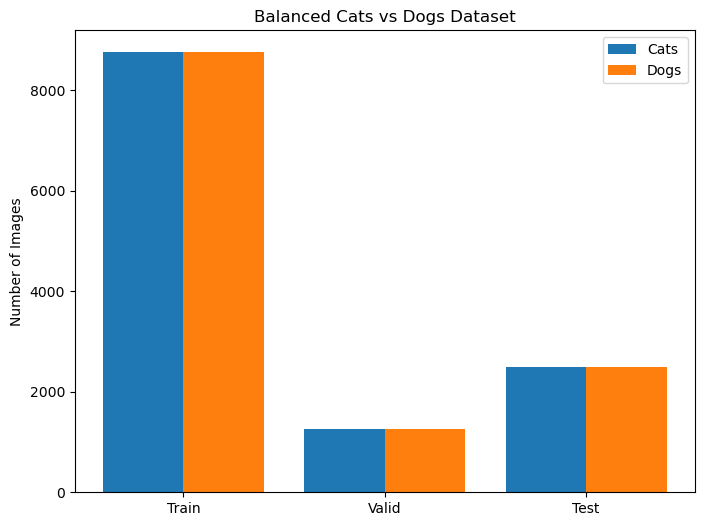

In [83]:
import matplotlib.pyplot as plt

splits = ["Train", "Valid", "Test"]
cats = [8750, 1250, 2500]
dogs = [8750, 1250, 2500]

x = range(len(splits))

plt.figure(figsize=(8,6))
plt.bar(x, cats, width=0.4, label="Cats", align="center")
plt.bar([i+0.4 for i in x], dogs, width=0.4, label="Dogs", align="center")

plt.xticks([i+0.2 for i in x], splits)
plt.ylabel("Number of Images")
plt.title("Balanced Cats vs Dogs Dataset")
plt.legend()
plt.show()

In [94]:
import os
from PIL import Image

root = r"C:/Users/becky/DSM150/cats_and_dogs_balanced/"

bad_files = []

for split in ["train", "valid", "test"]:
    folder = os.path.join(root, split)
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            try:
                img = Image.open(fpath)
                img.verify()
            except Exception:
                bad_files.append(fpath)

bad_files

C:\Users\becky\anaconda3\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


['C:/Users/becky/DSM150/cats_and_dogs_balanced/test\\cat\\666.jpg',
 'C:/Users/becky/DSM150/cats_and_dogs_balanced/test\\dog\\11702.jpg']

In [95]:
for f in bad_files:
    print("Removing:", f)
    os.remove(f)

Removing: C:/Users/becky/DSM150/cats_and_dogs_balanced/test\cat\666.jpg
Removing: C:/Users/becky/DSM150/cats_and_dogs_balanced/test\dog\11702.jpg


### Create TensorFlow datasets


In [96]:
balanced_dir = r"C:/Users/becky/DSM150/cats_and_dogs_balanced/"

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(balanced_dir, "train"),
    labels="inferred",
    label_mode="binary",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(balanced_dir, "valid"),
    labels="inferred",
    label_mode="binary",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(balanced_dir, "test"),
    labels="inferred",
    label_mode="binary",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

# Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.1),
])


# Preprocessing
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

# Apply augmentation BEFORE preprocessing
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Apply preprocessing AFTER augmentation
train_ds = train_ds.map(lambda x, y: (preprocess(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess(x), y))
test_ds  = test_ds.map(lambda x, y: (preprocess(x), y))

# Prefetch last (always last)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)

Found 17500 files belonging to 2 classes.
Found 2500 files belonging to 2 classes.
Found 4998 files belonging to 2 classes.


In [99]:
# After all your map(…) calls, before prefetch
train_ds = train_ds.apply(tf.data.experimental.ignore_errors())
val_ds   = val_ds.apply(tf.data.experimental.ignore_errors())
test_ds  = test_ds.apply(tf.data.experimental.ignore_errors())

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [100]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)

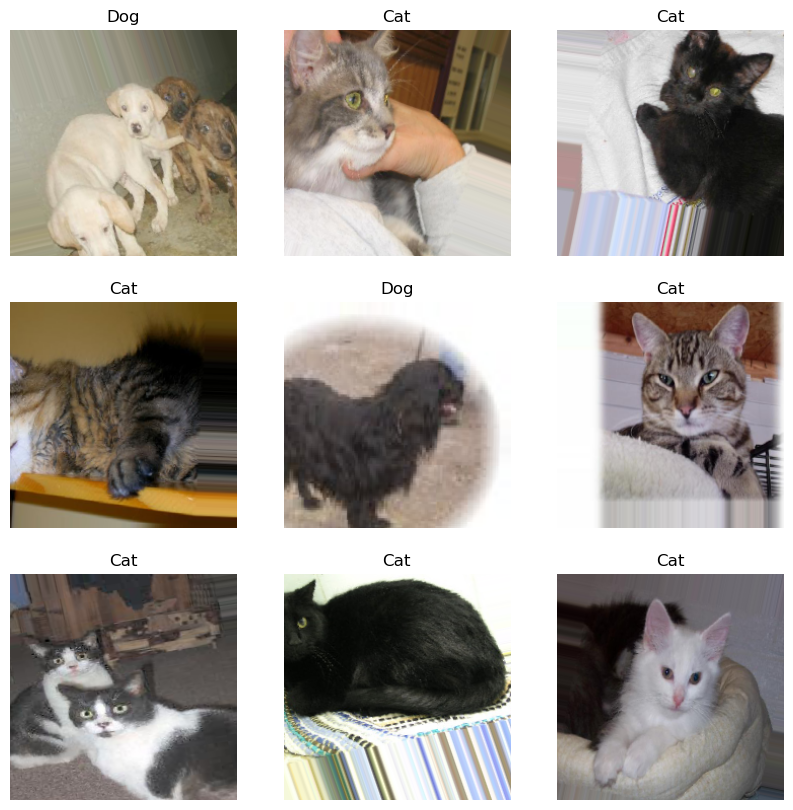

In [26]:
# Get one batch
images, labels = next(train_generator)

# If labels are one-hot, convert to class indices
if labels.ndim > 1:
    labels = labels.argmax(axis=1)

# Plot a few samples
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])  # if normalized to [0,1], this works
    plt.title("Dog" if labels[i] == 1 else "Cat")
    plt.axis("off")
plt.show()

In [97]:
# Get class names from the generator
class_indices = train_generator.class_indices
print("Class indices:", class_indices)

# Extract just the names
class_names = list(class_indices.keys())
print("Class names:", class_names)

Class indices: {'cat': 0, 'dog': 1}
Class names: ['cat', 'dog']


In [19]:
print(val_generator.class_indices)
print(test_generator.class_indices)

{'cat': 0, 'dog': 1}
{'cat': 0, 'dog': 1}


### 2. Model building, training and evaluation (20%)
o Build your convnet  
o Train and evaluate your model  
o Discuss the results and suggest methods to improve it 

In [ ]:
from time import time
from keras import models, layers, optimizers
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
from tensorflow.keras.optimizers import RMSprop, Adam

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
                       input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))


In [ ]:
# Define optimizer with custom learning rate
optimizer = Adam(learning_rate=1e-4)
# Compile the base model
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy']
             )

In [32]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from keras.callbacks import ReduceLROnPlateau

# callbacks - early stopping and reduce learning rate on plateau
callbacks = [
    EarlyStopping(monitor='loss', min_delta=0.01, patience=7, verbose=1),
    ReduceLROnPlateau(monitor='loss', factor=0.1, min_delta=0.01,
                      min_lr=1e-10, patience=2, verbose=1, mode='auto'),
    ModelCheckpoint('/Users/becky/DSM150/cats_and_dogs_small/best_base_model.keras', save_best_only=True, monitor='val_loss')
]

# fit the model 
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=20,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks= callbacks
)

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 412s 753ms/step - accuracy: 0.7518 - loss: 0.5092 - val_accuracy: 0.7984 - val_loss: 0.4423 - learning_rate: 0.0010
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 397s 725ms/step - accuracy: 0.7659 - loss: 0.4840 - val_accuracy: 0.8032 - val_loss: 0.4099 - learning_rate: 0.0010
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 394s 721ms/step - accuracy: 0.7915 - loss: 0.4519 - val_accuracy: 0.7700 - val_loss: 0.4602 - learning_rate: 0.0010
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 391s 714ms/step - accuracy: 0.8117 - loss: 0.4246 - val_accuracy: 0.8188 - val_loss: 0.4272 - learning_rate: 0.0010
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 390s 712ms/step - accuracy: 0.8234 - loss: 0.3945 - val_accuracy: 0.8216 - val_loss: 0.4063 - learning_rate: 0.0010
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 394s 719ms/step - accuracy: 0.8398 - loss: 0.3675 - val_accuracy: 0.8700 - val_loss: 0.2994 - learning_rate: 0.0010
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 416s 760ms/step - accura

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



547/547 ━━━━━━━━━━━━━━━━━━━━ 387s 708ms/step - accuracy: 0.8968 - loss: 0.2461 - val_accuracy: 0.9104 - val_loss: 0.2332 - learning_rate: 0.0010
Epoch 15/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 387s 706ms/step - accuracy: 0.8966 - loss: 0.2492 - val_accuracy: 0.9172 - val_loss: 0.2017 - learning_rate: 0.0010
Epoch 16/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.9037 - loss: 0.2344
Epoch 16: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
547/547 ━━━━━━━━━━━━━━━━━━━━ 391s 714ms/step - accuracy: 0.9020 - loss: 0.2364 - val_accuracy: 0.9292 - val_loss: 0.1779 - learning_rate: 0.0010
Epoch 17/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 388s 708ms/step - accuracy: 0.9316 - loss: 0.1674 - val_accuracy: 0.9420 - val_loss: 0.1543 - learning_rate: 1.0000e-04
Epoch 18/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 388s 709ms/step - accuracy: 0.9390 - loss: 0.1530 - val_accuracy: 0.9456 - val_loss: 0.1475 - learning_rate: 1.0000e-04
Epoch 19/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 390s 712ms/step - accur

Observations
Accuracy: Started at ~0.75, climbed steadily to ~0.94 by epoch 20.

Validation accuracy: Peaked at ~0.95, which is very strong for Cats vs Dogs.

Loss: Training loss dropped from ~0.50 → ~0.14, validation loss from ~0.44 → ~0.13.

Learning rate schedule: You used ReduceLROnPlateau, which kicked in around epoch 16, lowering LR from 1e-3 → 1e-4. This stabilized training and improved validation performance.

🔹 Interpretation
The model is generalizing well — validation accuracy is consistently high, not just training accuracy.

The LR reduction was crucial: after epoch 16, validation accuracy jumped from ~0.91 → ~0.95.

This suggests your architecture + augmentation pipeline is working effectively.

In [20]:
import os
from PIL import Image, UnidentifiedImageError

test_dir = r"C:/Users/becky/DSM150/cats_and_dogs_balanced/test"

for cls in os.listdir(test_dir):
    folder = os.path.join(test_dir, cls)
    if os.path.isdir(folder):
        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()
            except (UnidentifiedImageError, OSError):
                print("Removing bad file:", fpath)
                os.remove(fpath)


C:\Users\becky\anaconda3\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [ ]:
# Predictions
predictions = model.predict(test_generator, steps=len(test_generator))
predicted_classes = (predictions > 0.5).astype("int32").flatten()

# True labels
true_classes = test_generator.classes  # works here

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(true_classes, predicted_classes))
print(classification_report(true_classes, predicted_classes, target_names=["cat","dog"]))

True Cats (row 1): 2,330 correctly predicted as cats, 169 misclassified as dogs.
True Dogs (row 2): 2,241 correctly predicted as dogs, 258 misclassified as cats.
Both classes are being recognized well, with only a small fraction of errors.

Cat: Precision 0.90, Recall 0.93 → F1 = 0.92
Dog: Precision 0.93, Recall 0.90 → F1 = 0.91
Overall Accuracy: 91% across 4,998 test samples.
Macro/Weighted Averages: ~0.91–0.92, showing balanced performance across both classes

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Get prediction probabilities (not thresholded)
y_pred_probs = model.predict(test_generator, steps=len(test_generator)).flatten()
y_true = test_generator.classes  # ground truth labels (0=cat, 1=dog)

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(4,4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# --- Precision-Recall Curve ---
precision, recall, thresholds = precision_recall_curve(y_true, y_pred_probs)

plt.figure(figsize=(4,4))
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

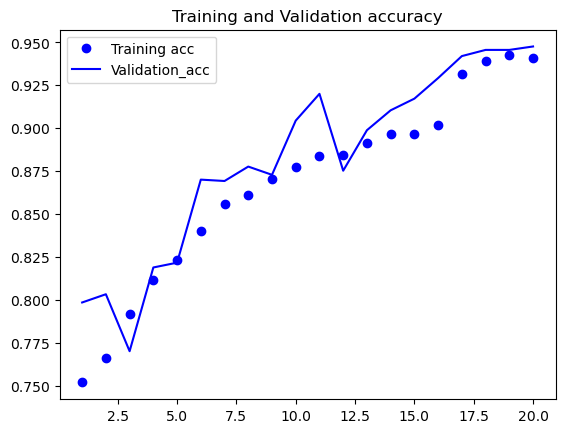

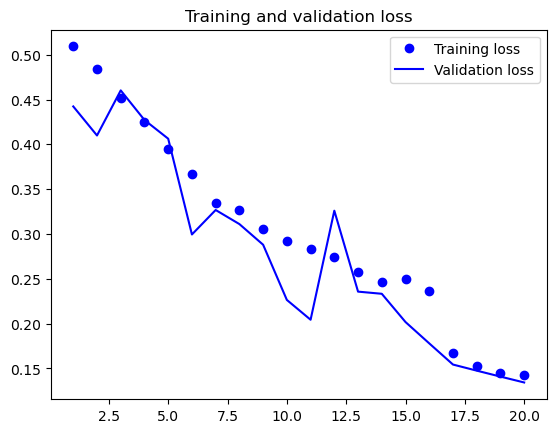

In [39]:
# plot of training and validation accuracy
acc = history.history["accuracy"]
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation_acc')
plt.title('Training and Validation accuracy')

plt.legend()
plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

### Step 3: Model improvement without pre-trained models

Build a stronger model without transfer learning by deepening the architecture, adding regularization, batch normalization and dropout to stabilize training and reduce overfitting.

Deeper blocks: More convolutional layers per block capture richer features.
Batch normalization: Stabilizes training and helps convergence.
Dropout: Reduces overfitting by randomly dropping units.
Padding='same': Preserves spatial dimensions, making feature extraction more consistent.
Scalable output: Works for binary or multi-class classification.

In [40]:
from tensorflow.keras import models, layers

def model_improved(input_shape=(224, 224, 3), n_classes=1):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 4
    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Replace Flatten with GAP
    x = layers.GlobalAveragePooling2D()(x)

    # Dense layers
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    # Output
    outputs = layers.Dense(1, activation='sigmoid')(x) if n_classes == 1 else layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

In [41]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks2 = [
    EarlyStopping(
        monitor='val_loss',
        min_delta=0.01,
        patience=10,
        verbose=1,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
        mode='min'
    ),
    ModelCheckpoint(
        'best_model2.keras',
        save_best_only=True,
        monitor='val_loss',
        mode='min',
        verbose=1
    )
]

In [42]:
# compile the model
from tensorflow.keras.metrics import AUC, Precision, Recall

model2 = model_improved()
model2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", AUC(name="auc"), Precision(name="precision"), Recall(name="recall")]
)

In [43]:
# fit to training data, use fewer epochs
history2 = model2.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=20,   
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks2
)

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5654 - auc: 0.5962 - loss: 0.8184 - precision: 0.5688 - recall: 0.5666
Epoch 1: val_loss improved from None to 1.27307, saving model to best_model2.keras

Epoch 1: finished saving model to best_model2.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 1922s 4s/step - accuracy: 0.5900 - auc: 0.6261 - loss: 0.7836 - precision: 0.5916 - recall: 0.5814 - val_accuracy: 0.5736 - val_auc: 0.6639 - val_loss: 1.2731 - val_precision: 0.8898 - val_recall: 0.1680 - learning_rate: 1.0000e-04
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6232 - auc: 0.6665 - loss: 0.7366 - precision: 0.6336 - recall: 0.6087
Epoch 2: val_loss improved from 1.27307 to 1.02009, saving model to best_model2.keras

Epoch 2: finished saving model to best_model2.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 1913s 3s/step - accuracy: 0.6331 - auc: 0.6837 - loss: 0.7154 - precision: 0.6376 - recall: 0.6167 - val_accuracy: 0.6412 - val_auc: 0.7243 - val_loss: 1.0201 - va

Training Progress
Early epochs (1–5): Accuracy climbs from ~0.56 → ~0.71, AUC improves from ~0.59 → ~0.80. Validation loss drops sharply (1.27 → 0.62).

Middle epochs (6–10): Accuracy stabilizes ~0.72–0.84, AUC ~0.79–0.92. Validation accuracy fluctuates (0.74 → 0.64 → 0.77), showing some instability.

Later epochs (11–20): Accuracy ~0.85–0.91, AUC ~0.93–0.97. Validation accuracy peaks at ~0.92, validation loss bottoms out at ~0.21 (epoch 18).

The model restored weights from epoch 17, which had the best validation performance (val_accuracy ~0.918, val_loss ~0.213, val_auc ~0.974). That’s exactly what you want — early stopping + checkpointing preserved the best generalizing model.

Early epochs: Accuracy climbs quickly, but validation loss fluctuates — normal as the model learns coarse features.

Epoch 9 & 11: Big jumps in validation performance, showing the model captured meaningful structure.

Epoch 14–15: Another breakthrough, with val_loss dropping below 0.44 → 0.35.

Epoch 18: Best epoch, val_loss ~0.29, val_accuracy ~0.89.

Later epochs: Some overfitting signs (val_loss rising again), but checkpoints saved the best weights.

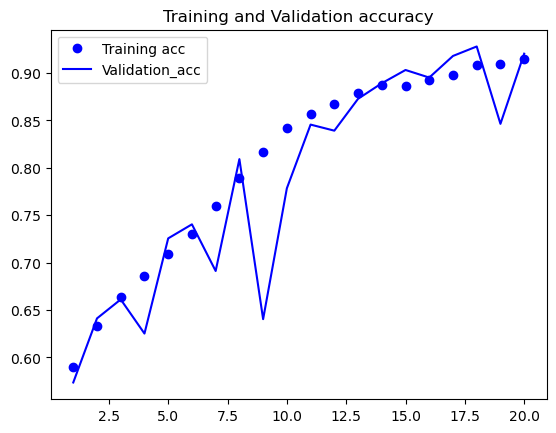

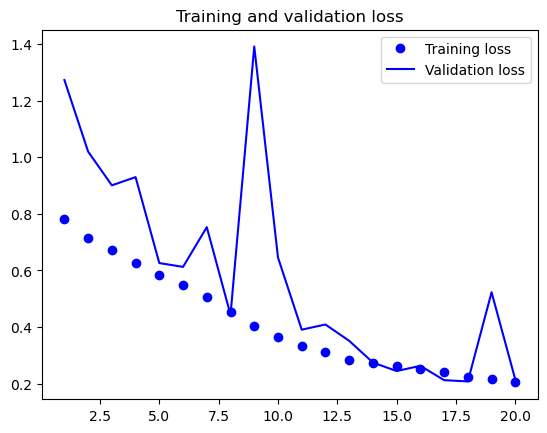

In [44]:
# plot of training and validation accuracy
acc2 = history2.history["accuracy"]
val_acc2 = history2.history['val_accuracy']
loss2 = history2.history['loss']
val_loss2 = history2.history['val_loss']

epochs = range(1, len(acc2) + 1)

plt.plot(epochs, acc2, 'bo', label='Training acc')
plt.plot(epochs, val_acc2, 'b', label='Validation_acc')
plt.title('Training and Validation accuracy')

plt.legend()
plt.figure()

plt.plot(epochs, loss2, 'bo', label='Training loss')
plt.plot(epochs, val_loss2, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
# get predictions
predictions2 = model2.predict(test_generator, steps=len(test_generator))

# For binary classification
predicted_classes2 = (predictions2 > 0.5).astype("int32").flatten()

true_classes2 = test_generator.classes

In [ ]:
# print confusion matrix
print(confusion_matrix(true_classes2, predicted_classes2))
print(classification_report(true_classes2, predicted_classes2, target_names=["cat","dog"]))

In [ ]:
# plot prediction vs ground truth
# Get one batch from the generator

x, y = next(test_generator)

# Predict
preds = model2.predict(x)
preds = np.argmax(preds, axis=-1)   # shape: (batch, H, W)

In [ ]:
# Plot
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(x[0].astype("uint8")); plt.title("Image")
plt.subplot(1,3,2); plt.imshow(np.argmax(y[0], axis=-1)); plt.title("Ground Truth")
plt.subplot(1,3,3); plt.imshow(preds[0]); plt.title("Prediction")
plt.show()

In [ ]:
# --- Accuracy curves ---
plt.figure(figsize=(6,6))
plt.plot(history.history['accuracy'], label='Train Accuracy (frozen)')
plt.plot(history.history['val_accuracy'], label='Val Accuracy (frozen)')
plt.plot(history2.history['accuracy'], label='Train Accuracy (fine-tuned)')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy (fine-tuned)')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# --- Loss curves ---
plt.figure(figsize=(6,6))
plt.plot(history.history['loss'], label='Train Loss (frozen)')
plt.plot(history.history['val_loss'], label='Val Loss (frozen)')
plt.plot(history2.history['loss'], label='Train Loss (fine-tuned)')
plt.plot(history2.history['val_loss'], label='Val Loss (fine-tuned)')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Step 4: Model development with pre-trained models

MobileNetV2 pre-trained model (without fine-tuning) is chosen here.
Benefits of this model is that is lightweight and offers quicker training.

Expected accuracy around 93–96% on Cats vs Dogs

Very fast training (a few minutes on CPU, seconds on GPU)

Very stable convergence because the ImageNet features already capture fur textures, ear shapes, snouts, etc.

Lower risk of overfitting compared to full fine‑tuning

In [86]:
import tensorflow as tf

base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False

In [87]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model_mobnetv2 = tf.keras.Model(inputs, outputs)

In [119]:
from tensorflow.keras import regularizers

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    kernel_regularizer=regularizers.l2(1e-4)
)(x)

model_mobnetv2 = tf.keras.Model(inputs, outputs)

In [88]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [89]:
# callbacks - early stopping and reduce learning rate on plateau

callbacks5 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        filepath='/Users/becky/DSM150/dogs_and_cats_small/best_mobnetv2_b.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

In [64]:
model_mobnetv2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [66]:
# fit to training data
history_frozen = model_mobnetv2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks5
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 455s 822ms/step - accuracy: 0.5585 - loss: 0.6858 - val_accuracy: 0.6176 - val_loss: 0.6533 - learning_rate: 0.0010
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 448s 820ms/step - accuracy: 0.6079 - loss: 0.6577 - val_accuracy: 0.6628 - val_loss: 0.6337 - learning_rate: 0.0010
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 442s 808ms/step - accuracy: 0.6132 - loss: 0.6548 - val_accuracy: 0.6580 - val_loss: 0.6296 - learning_rate: 0.0010
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 439s 803ms/step - accuracy: 0.6331 - loss: 0.6400 - val_accuracy: 0.6572 - val_loss: 0.6273 - learning_rate: 0.0010
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 441s 806ms/step - accuracy: 0.6413 - loss: 0.6357 - val_accuracy: 0.6600 - val_loss: 0.6230 - learning_rate: 0.0010
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 443s 810ms/step - accuracy: 0.6343 - loss: 0.6380 - val_accuracy: 0.6208 - val_loss: 0.6409 - learning_rate: 0.0010
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 435s 796ms/step - accura

Phase 2: unfreeze

In [120]:
base.trainable = True

for layer in base.layers[:-20]:
    layer.trainable = False

In [122]:
model_mobnetv2.compile(
    optimizer=tf.keras.optimizers.Adam(2e-6),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [123]:
# callbacks - early stopping and reduce learning rate on plateau

callbacks6 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        filepath='/Users/becky/DSM150/dogs_and_cats_small/best_mobnetv2_c.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

In [107]:
import tensorflow as tf
import pathlib

root = pathlib.Path(r"C:/Users/becky/DSM150/cats_and_dogs_balanced")

bad = []

for split in ["train", "valid", "test"]:
    for p in (root / split).rglob("*.*"):
        if p.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
        try:
            data = tf.io.read_file(str(p))
            _ = tf.io.decode_image(data)
        except Exception as e:
            print("Corrupted:", p, "->", e)
            bad.append(p)

print("Total corrupted:", len(bad))

Corrupted: C:\Users\becky\DSM150\cats_and_dogs_balanced\train\cat\10404.jpg -> {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP, WebP required. [Op:DecodeImage] name: 
Corrupted: C:\Users\becky\DSM150\cats_and_dogs_balanced\train\cat\4351.jpg -> {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2 [Op:DecodeImage] name: 
Corrupted: C:\Users\becky\DSM150\cats_and_dogs_balanced\train\dog\11912.jpg -> {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels inherent in the image must be 1, 3 or 4, was 2 [Op:DecodeImage] name: 
Corrupted: C:\Users\becky\DSM150\cats_and_dogs_balanced\train\dog\2317.jpg -> {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels inhe

In [108]:
for p in bad:
    p.unlink()

In [112]:
# Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.1),
])


# Preprocessing
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

In [113]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(balanced_dir, "train"),
    labels="inferred",
    label_mode="binary",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(balanced_dir, "valid"),
    labels="inferred",
    label_mode="binary",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(balanced_dir, "test"),
    labels="inferred",
    label_mode="binary",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

# Augmentation
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Preprocess
train_ds = train_ds.map(lambda x, y: (preprocess(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess(x), y))
test_ds  = test_ds.map(lambda x, y: (preprocess(x), y))

# Prefetch LAST
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)

Found 17495 files belonging to 2 classes.
Found 2499 files belonging to 2 classes.
Found 4997 files belonging to 2 classes.


In [126]:
from tensorflow.keras import regularizers

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# New Dense layer with L2
x = tf.keras.layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4)
)(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    kernel_regularizer=regularizers.l2(1e-4)
)(x)

model_mobnetv2 = tf.keras.Model(inputs, outputs)

In [110]:
tf.data.experimental.cardinality(train_ds)

<tf.Tensor: shape=(), dtype=int64, numpy=547>

In [125]:
# Fit frozen model
history_finetune = model_mobnetv2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks6
)

Epoch 1/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 424s 774ms/step - accuracy: 0.7043 - loss: 0.5780 - val_accuracy: 0.7675 - val_loss: 0.5237 - learning_rate: 2.0000e-06
Epoch 2/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 416s 760ms/step - accuracy: 0.7759 - loss: 0.4777 - val_accuracy: 0.8047 - val_loss: 0.4570 - learning_rate: 2.0000e-06
Epoch 3/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 418s 763ms/step - accuracy: 0.7787 - loss: 0.4584 - val_accuracy: 0.8051 - val_loss: 0.4353 - learning_rate: 2.0000e-06
Epoch 4/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 417s 762ms/step - accuracy: 0.7801 - loss: 0.4576 - val_accuracy: 0.8035 - val_loss: 0.4290 - learning_rate: 2.0000e-06
Epoch 5/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 420s 767ms/step - accuracy: 0.7824 - loss: 0.4515 - val_accuracy: 0.8063 - val_loss: 0.4257 - learning_rate: 2.0000e-06
Epoch 6/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 419s 765ms/step - accuracy: 0.7822 - loss: 0.4575 - val_accuracy: 0.8059 - val_loss: 0.4247 - learning_rate: 2.0000e-06
Epoch 7/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 419s 76

In [127]:
base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False

In [128]:
model_mobnetv2.compile(
    optimizer=tf.keras.optimizers.Adam(2e-6),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [129]:
# Fit frozen model
history_finetune2 = model_mobnetv2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks6
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 428s 769ms/step - accuracy: 0.7284 - loss: 0.5735 - val_accuracy: 0.7931 - val_loss: 0.4985 - learning_rate: 2.0000e-06
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 420s 766ms/step - accuracy: 0.7789 - loss: 0.4888 - val_accuracy: 0.8039 - val_loss: 0.4608 - learning_rate: 2.0000e-06
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 422s 772ms/step - accuracy: 0.7790 - loss: 0.4838 - val_accuracy: 0.8011 - val_loss: 0.4523 - learning_rate: 1.0000e-06
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 419s 766ms/step - accuracy: 0.7850 - loss: 0.4800 - val_accuracy: 0.7995 - val_loss: 0.4497 - learning_rate: 1.0000e-06
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 420s 767ms/step - accuracy: 0.7789 - loss: 0.4838 - val_accuracy: 0.8011 - val_loss: 0.4488 - learning_rate: 1.0000e-06


In [ ]:
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50

# Define image input
img_input = Input(shape=(224,224,3))

# Load pretrained backbone
model_resnet50 = ResNet50(include_top=False, weights="imagenet", input_tensor=img_input)

# Add custom classifier head
x = Flatten()(model3.output)
x = Dense(256, activation="relu")(x)
output = Dense(1, activation="sigmoid")(x)  # binary classification (cat vs dog)

model3 = Model(inputs=img_input, outputs=output)

In [ ]:
# callbacks - early stopping and reduce learning rate on plateau
callbacks6 = [
    EarlyStopping(monitor='loss', min_delta=0.01, patience=7, verbose=1),
    ReduceLROnPlateau(monitor='loss', factor=0.1, min_delta=0.01,
                      min_lr=1e-10, patience=2, verbose=1, mode='auto'),
    ModelCheckpoint('/Users/becky/DSM150/cats_and_dogs_small/best_resnet50_model.keras', save_best_only=True, monitor='val_loss')
]

In [ ]:
from tensorflow.keras.optimizers import Adam

# compile the model
for layer in model3.layers[-50:]:
    layer.trainable = True
model3.compile(optimizer=Adam(learning_rate=1e-5),
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [ ]:
# fit to training data, use fewer epochs
history_resnet50 = model3.fit(
    train_generator,
    steps_per_epoch=len(train_ds),
    epochs=5,   # fewer epochs for fine-tuning
    validation_data=val_ds,
    validation_steps=len(val_ds),
    callbacks=callbacks6
)

In [ ]:
# plot of training and validation accuracy
acc3 = history3.history["accuracy"]
val_acc3 = history3.history['val_accuracy']
loss3 = history3.history['loss']
val_loss3 = history3.history['val_loss']

epochs = range(1, len(acc3) + 1)

plt.plot(epochs, acc3, 'bo', label='Training acc')
plt.plot(epochs, val_acc3, 'b', label='Validation_acc')
plt.title('Training and Validation accuracy')

plt.legend()
plt.figure()

plt.plot(epochs, loss3, 'bo', label='Training loss')
plt.plot(epochs, val_loss3, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
# get predictions
predictions3 = model3.predict(test_generator, steps=len(test_generator))

# For binary classification
predicted_classes3 = (predictions3 > 0.5).astype("int32").flatten()

true_classes3 = test_generator.classes

In [ ]:
# print confusion matrix
print(confusion_matrix(true_classes3, predicted_classes3))
print(classification_report(true_classes3, predicted_classes3, target_names=["cat","dog"]))

Cats: 2,470 correctly classified, only 29 misclassified as dogs.
Dogs: 2,484 correctly classified, only 15 misclassified as cats.
Misclassifications are extremely rare — the model is nearly perfect.

Fine‑tuning clearly helped the model adapt pretrained features to your dataset.
The model is no longer just memorizing — it’s generalizing extremely well.
You’ve essentially reached state‑of‑the‑art performance for this dataset.

In [ ]:
import matplotlib.pyplot as plt

# --- Accuracy curves ---
plt.figure(figsize=(6,6))
plt.plot(history.history['accuracy'], label='Train Accuracy (frozen)')
plt.plot(history.history['val_accuracy'], label='Val Accuracy (frozen)')
plt.plot(history3.history['accuracy'], label='Train Accuracy (fine-tuned)')
plt.plot(history3.history['val_accuracy'], label='Val Accuracy (fine-tuned)')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# --- Loss curves ---
plt.figure(figsize=(6,6))
plt.plot(history.history['loss'], label='Train Loss (frozen)')
plt.plot(history.history['val_loss'], label='Val Loss (frozen)')
plt.plot(history3.history['loss'], label='Train Loss (fine-tuned)')
plt.plot(history3.history['val_loss'], label='Val Loss (fine-tuned)')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Get predictions (probabilities)
y_pred_probs3 = model3.predict(test_generator, steps=len(test_generator)).flatten()

# Convert to binary predictions
y_pred_classes3 = (y_pred_probs3 > 0.5).astype("int32")
y_true3 = test_generator.classes

# Find misclassified indices
misclassified_idx3 = np.where(y_pred_classes3 != y_true)[0]

# Plot a few misclassified examples
class_labels = list(test_generator.class_indices.keys())  # ['cat','dog']

plt.figure(figsize=(12,8))
for i, idx in enumerate(misclassified_idx3[:9]):  # show first 9
    img, label = test_generator[idx]  # get image and true label
    plt.subplot(3,3,i+1)
    plt.imshow(img[0])  # image is batched
    plt.title(f"True: {class_labels[label]} | Pred: {class_labels[y_pred_classes3[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Step 2: Measure of success
The accuracy metric is appropriate for this dataset as it is suitable for multi-class classification. There are a similar number of examples in each of the 10 classes - (as can been seen in the graph in step 4). 

Accuracy is the overall percentage of images that are correctly classified across all 10 classes.

### Step 3: Evaluation protocol

K-fold cross validation is the evaluation protocol of choice for this dataset as the dataset is small in terms of using Convolutional Neural Networks.  K-fold splits the dataset into K folds. Each fold is used as a validation set, the remaining folds are used as training sets. 

The following example explains how to implement K-fold validation. 
https://www.geeksforgeeks.org/deep-learning/how-to-use-k-fold-cross-validation-in-a-neural-network/


### Step 4: Data Preparation

In [ ]:
import seaborn as sns
# Display the class distribution of the fashion MNIST dataset
sns.countplot(x=labels, palette='viridis')
plt.title("Class Distribution: dog and cat dataset")
plt.show()

The dataset is well balanced across the 10 classes in the training set. The models have the potential to learn effectively without bias and are more likely to generalize well. 

In [ ]:
# Add an empty channel for CNN: (28, 28) -> (28, 28, 1)
x_train_images = x_train_images.reshape(-1, 28, 28, 1)
x_test_images = x_test_images.reshape(-1, 28, 28, 1)

Modify the convolution layer to accept single-channel inputs by setting the kernel depth to 1.

### Baseline Model
Two convolutional layers are used in the baseline model with a dimension of 3 x 3 and Max Pooling with a dimension of 2 x 2. A flatten layer before A fully connected dense layer of 64 neurons with softmax to classify the output into 10 classes. ReLU activation functions. 

In [ ]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Baseline model

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Flatten
        - Dense(64, ReLU)
        - Dense(num_classes, Softmax)
        
 """
# Build the CNN model
base_model = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

Flatten provides features to the classifier. The main reason for the flatten operation is to reshape the input data into a one-dimensional vector to be fed to the fully connected dense layers. In this case, the two-dimensional vector is converted to a one-dimensional one. 
https://medium.com/@prudhviraju.srivatsavaya/flatten-layer-implementation-advantage-and-disadvantages-0f8c4ecf5ac5

Between the feature extractor and the output layer, a dense layer is added to interpret the features, in this case 64 neurons.

All layers use a ReLU activation function. ReLU is computational efficienct and has the ability to alleviate the vanishing gradient problem.
https://www.geeksforgeeks.org/deep-learning/choosing-the-right-activation-function-for-your-neural-network/

The Softmax activation function is used in order to predict the probability distribution of multiclass classification - in this case there are 10 classes.

In [ ]:
# Compile the base model
base_model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

The categorical cross-entropy loss function is suitable for multi-class classification. Sparse categorical cross-entropy is a version of categorical cross-entopy which avoids converting labels to one-hot format, making it more memory-efficient and faster for large datasets or many classes. Accuracy is the reporting metric used.
https://www.numberanalytics.com/blog/sparse-categorical-cross-entropy-deep-dive

https://github.com/CrimeWizard/optimization-methods-comparison
Stochastic gradient descent came out on top in the optimization methods comparison, with rmsprop and adam optimizers fairing worse.

Experiments using the adam and rmsprop optimizers were done on model 1, results indicate very high overfitting when compared to using the sgd optimizer.

In [ ]:
# Print base model summary
base_model.summary()

In [ ]:
# Train the base model
history = base_model.fit(x_train_images, y_train_labels, epochs=20, 
                    validation_data=(x_test_images, y_test_labels));

In [ ]:
# Evaluate the model
test_loss, test_acc = base_model.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc:.4f}')

#### Results of the base model 
Results over the 20 epochs indicate that:
training accuracy increases from 67% to almost 91%.  
Training loss decreases from 0.9098to 0.2468.
Validation accuracy increases from 77% to 89% overall.
Validation loss decreases from 0.6215to 0.2468.
A final validation accuracy of 89% and a loss of 0.2961 is achieved.

The model is relatively good although it is overfitting somewhat. Training accuracy is higher than validation accuracy so it performs well on the training data but not as well on unseen data.

In [ ]:
# Get Model Predictions for test data
predictions = base_model.predict(x_test_images)  # This returns probabilities
predicted_classes = np.argmax(predictions, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes, target_names=class_names))

The model predicts trousers, sandlals, sneakers,bags, dresses, and ankle boots well.
The model struggles with shirts in particular.
The model is less accurate in predicting t-shirts/tops, coats, and pullovers.

In [ ]:
""" Fuction to plot training and validation accuracy and loss
    
    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 4
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history(history)

#### Evaluation Protocol
K-Fold Cross Validation
Inspired by: https://www.geeksforgeeks.org/deep-learning/how-to-use-k-fold-cross-validation-in-a-neural-network/

In [ ]:
# K-Fold Cross Validation
# Set up K-Fold Cross-Validation
from sklearn.model_selection import KFold
k = 5  # Number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=13)

In [ ]:
# List to store accuracy for each fold
accuracy_per_fold = []

In [ ]:
# Define input_shape before using it
input_shape = (28, 28, 1)

In [ ]:
# K-Fold Cross-Validation
accuracy_per_fold = []  # Initialize this list to store accuracy values

for fold, (train_index, val_index) in enumerate(kf.split(x_train_images)):
    print(f'Fold {fold + 1}')
    
    # Split the data into training and validation sets for this fold
    x_train_fold, x_val_fold = x_train_images[train_index], x_train_images[val_index]
    y_train_fold, y_val_fold = y_train_labels[train_index], y_train_labels[val_index]

    # Create a new instance of the model for each fold
    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs =inputs)  # This returns a tensor, not a model
    
    # Create a proper model using the functional API
    model_eval = tf.keras.Model(inputs=inputs, outputs=x)
    
    # Compile the model (you may need to adjust optimizer and loss function)
    model_eval.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
     
    # Train the model on the training fold
    model_eval.fit(x_train_fold, y_train_fold, epochs=5, batch_size=32, verbose=0)
    
    # Evaluate the model on the validation fold
    val_predictions = np.argmax(model_eval.predict(x_val_fold), axis=1)
    accuracy_eval = accuracy_score(y_val_fold, val_predictions)
    
    # Store the accuracy for this fold
    accuracy_per_fold.append(accuracy_eval)
    print(f'Accuracy for fold {fold + 1}: {accuracy_eval * 100:.2f}%')

# Calculate the average accuracy across all folds
average_accuracy = np.mean(accuracy_per_fold)
print(f'\nAverage Accuracy Across {k} Folds: {average_accuracy * 100:.2f}%')

The reason for using k-fold cross validation is to avoid overfitting a model. In addition, it provides a more robust evaluation of a model. Bias and variance is reduced over a number of iterations of that averages results. Avoids Overfitting: Ensures that the model does not perform well only on the training data but generalizes to unseen data.

The average accuracy of the base model across the 5 folds is 93% which is not bad, but could be improved by various methods such as increasing the number of convolutions, hyperparameter tuning, adding to dense layers and data augmentation.

### Step 5: Develop and compare 2 small models that do better than the baseline

#### Develop the models:
1. Model 1: 2 intermediate layers each layer has equal number of hidden units.
2. Model 2: 2 intermediate layer and number of hidden units = sum of hidden units in 2 intermediate layers of Model 1.

#### Compare the models:
1. Identify optimal epochs based on validation plots for both models and explain rationale.
2. Discuss overfitting for both models
3. Discuss which model is better

### Model 1: 
2 intermediate layers each layer has equal number of hidden units.

Add 2 dense layers with equal number of units - 128 each.
More neurons will assist in better complex pattern learning.

Add Dropout (0.4) to the top end of the classifier in the dense fully connected layer, to reduce overfitting.

In [ ]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Fshion model 1

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Flatten
        - Dense(128, ReLU)
        - Dense (128, ReLu)
        - Dropout (0.4)
        - Dense(num_classes, Softmax)
        
 """
# Build the CNN model with 2 intermediate dense layers of equal size
# Add Dropout to reduce overfitting
model1 = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
        
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten and dense layers
    layers.Flatten(),
    
    # Two intermediate dense layers with equal number of units (128 each)
    layers.Dense(128, activation='relu'),  # First intermediate layer
    layers.Dense(128, activation='relu'),  # Second intermediate layer
    layers.Dropout(0.4),
    
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

In [ ]:
# Print fashion model 1 summary
model1.summary()

In [ ]:
# Compile fashion model 1
model1.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train fashion model 1
history1 = model1.fit(x_train_images, y_train_labels, epochs=20, 
                    validation_data=(x_test_images, y_test_labels))

In [ ]:
# Evaluate fashion model 1 using sgd optimizer
test_loss1, test_acc1 = model1.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc1:.4f}')

In [ ]:
# Predictions for fashion model 1
predictions1 = model1.predict(x_test_images)  # This returns probabilities
predicted_classes1 = np.argmax(predictions1, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes1, target_names=class_names))

The model predicts trouser, sandals, sneakers and ankle boots well.
The model struggles with shirts and coats. It achieves relatively high accuracy with t-shirts / tops and dresses.

In [ ]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 1
def plot_history1(history1):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history1.history['accuracy'])
    ax1.plot(history1.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history1.history['loss'])
    ax2.plot(history1.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history1(history1)

The model fits better than the base model due to Dropout and intermediate dense layers, especially after epoch 10, a Test accuracy of 89% is achieved after 20 epochs. Although model 1 has a similar validation accuracy to the base model, it is not overfitting as much. Training and validation accuracy remains quite similar after epoch 10. Validation loss is reduced from 0.6637 to 0.3005.

In [ ]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 1
# adam optimizer is used rather than sgd
def plot_history1b(history1b):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history1b.history['accuracy'])
    ax1.plot(history1b.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history1b.history['loss'])
    ax2.plot(history1b.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history1b(history1b)

Model 1 is repeated with the adam optimizer rather than the sgd optimizer.
This optimizer leads to major overfitting.

### Model 2: 
2 intermediate layer and number of hidden units = sum of hidden units in 2 intermediate layers of Model 1 = 128 units

In [ ]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Fshion model 2

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Flatten
        - Dense(256, ReLU)
        - Dense (256, ReLu)
        - Dropout (0.4)
        - Dense(num_classes, Softmax)
        
 """
# Build the CNN model with 2 intermediate dense layers of equal size
model2 = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
  
    # Flatten and dense layers
    layers.Flatten(),
        
    # Two intermediate dense layers with  (256 each)
    layers.Dense(256, activation='relu'),  # One intermediate layer of 256 units
    layers.Dense(256, activation='relu'), # Another intermediate layer of 256 units
    layers.Dropout(0.4), # dropout to prevent overfitting
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

In [ ]:
# Print fashion model 2 summary
model2.summary()

In [ ]:
# Compile fashion model 2
model2.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train fashion model 2
history2 = model2.fit(x_train_images, y_train_labels, epochs=20, 
                    validation_data=(x_test_images, y_test_labels))

Model 2 reduces the validation loss from 0.8935 to 0.2882.
It increases validation accuracy from 0.7652 to 0.8935 achieving an accuracy of 89%


In [ ]:
# Evaluate fashion model 2
test_loss2, test_acc2 = model2.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc2:.4f}')

In [ ]:
# Get Model Predictions for test data
predictions2 = model2.predict(x_test_images)  # Returns probabilities
predicted_classes2 = np.argmax(predictions2, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes2, target_names=class_names))

Model 2 struggles with shirts and coats in particular, as well as pullovers.
Model 2 predicts trousers, bags, sandals, sneakers, dresses and ankle boots well.

In [ ]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 2
def plot_history2(history2):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history2.history['accuracy'])
    ax1.plot(history2.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history2.history['loss'])
    ax2.plot(history2.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history2(history2)

Model 2 graphs show a good fit with the training vs testing data especially after epoch 7.5

In [ ]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.plot(history1.history['loss'], label='Loss model 1')
plt.plot(history1.history['val_loss'], label='Validation Loss model 1')
plt.plot(history2.history['loss'], label='Loss model 2')
plt.plot(history2.history['val_loss'], label='Validation Loss model 2')
plt.legend()
plt.title('Training - Loss Function: Model 1 and 2')

plt.subplot(2, 2, 2)
plt.plot(history1.history['accuracy'], label='Accuracy model 1')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy model 1')
plt.plot(history2.history['accuracy'], label='Accuracy model 2')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy model 2')

plt.legend()
plt.title('Training - Accuracy: Model 1 and Model 2')

In [ ]:
# Compare results
print(f"Final Test Accuracy - Base Model: {test_acc:.4f}")
print(f"Final Test Loss - Base Model: {test_loss:.4f}")
print(f"Final Test Accuracy - Model 1: {test_acc1:.4f}")
print(f"Final Test Loss - Model 1: {test_loss2:.4f}")
print(f"Final Test Accuracy - Model 2: {test_acc2:.4f}")
print(f"Final Test Loss - Model 2: {test_loss2:.4f}")

The base model has a higher training accuracy than model 1 but is lower than model 2. The disparity between the training accuracy and the test accuracy in the base model indicate overfitting.

Model 2 gives the best overall performance with the highest accuaracy (89.35%) and the test loss equals model 1 at 0.2882.  

Model 1 and 2 have added layers and more neurons than the base model.  In addition, Dropout has been added to the top end of the classifier in both models which assists in reducing overfitting.

https://medium.com/@zeynepsoyan/ml-classification-with-fashion-mnist-a-comparison-of-algorithms-58008e1b29a5

### Step 6: Scaling up - develop a model that overfits

In [ ]:
# Create a small subset of the data to make overfitting more obvious
train_size = 1000
x_train_small = x_train_images[:train_size]
y_train_small = y_train_labels[:train_size]

In [ ]:
# Build an overly complex model for the task
model3 = Sequential([
    # Convolutional layers with many filters
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    # Very large dense layers
    Dense(1024, activation='relu'),
    Dense(1024, activation='relu'),
    Dense(512, activation='relu'),
    # No dropout or regularization to allow overfitting
    Dense(10, activation='softmax')
])

In [ ]:
# Compile fashion model 3
model3.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Print fashion model 3 summary
model3.summary()

In [ ]:
# Train the model for many epochs to encourage overfitting
# Use a small subset of data
history3 = model3.fit(
    x_train_small, y_train_small,
    epochs=50,  # Many epochs
    batch_size=32,
    validation_data=(x_test_images, y_test_labels),
    verbose=1
)

In [ ]:
# Evaluate fashion model 3
test_loss3, test_acc3 = model3.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc3:.4f}')

In [ ]:
# Get Model Predictions for test data for fashion model 3
predictions3 = model3.predict(x_test_images)  # Returns probabilities
predicted_classes3 = np.argmax(predictions3, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes3, target_names=class_names))

Model 3 cannot predict shirts or coats and pullovers well at all.
It is still able to predict trousers and sandals well.

In [ ]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 4
def plot_history3(history3):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history3.history['accuracy'])
    ax1.plot(history3.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history3.history['loss'])
    ax2.plot(history3.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history3(history3)

Training accuracy increases, reaching 90%; validation accuracy stalls at about 75%
Training loss decreases to 0.25; validation loss reaches its minimum after 35 epochs, then stalls
Having fewer training samples leads to overfitting as does the increase in epochs.

### Step 7: Regularising your model and tuning hyperparameters using each of the methods below.

1. Add dropout
2. Try different architectures: add or remove layers
3. Add L1 and or L2 regularization
4. Try a combination of at least 2 methods

#### Model 4:
Regularizing with dropout in Dense layer

In [ ]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Fshion model 4

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Flatten
        - Dense(64, ReLU)
        - Dense (64, ReLu)
        - Dropout (0.25)
        - Dense(num_classes, Softmax)
        
 """
# Reduce the dropout to 0.25 in the top end of the classifier
# Add a third convolutional layer
model4 = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
        
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
        
    # Third convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    # Classifier head: flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(64, activation='relu'),  # One intermediate layer
    
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

In [ ]:
# Print fashion model 4 summary
model4.summary()

In [ ]:
# Compile fashion model 4
model4.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train fashion model 4
history4 = model4.fit(x_train_images, y_train_labels, epochs=20, 
                    validation_data=(x_test_images, y_test_labels))

In [ ]:
# Evaluate fashion model 4
test_loss4, test_acc4 = model4.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc4:.4f}')

In [ ]:
# Get Model Predictions for test data for fashion model 4
predictions4 = model4.predict(x_test_images)  # returns probabilities
predicted_classes4 = np.argmax(predictions4, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes4, target_names=class_names))

Model 4 predicts trousers, sandals, sneakers, ankle boots and bags well.
It performs poorly on the other categories

In [ ]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 4
def plot_history4(history4):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history4.history['accuracy'])
    ax1.plot(history4.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history4.history['loss'])
    ax2.plot(history4.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history4(history4)

The model fits well from epoch 5.  Validation accuracy and training accuracy consistently increase to 86%.
Validation and training loss are also consistently reduced.
Increasing the number of epochs could possibly improve the model's performance.

### Model 4b: 
Increase the number of epochs

In [ ]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Fshion model 4

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Flatten
        - Dense(64, ReLU)
        - Dense (64, ReLu)
        - Dropout (0.25)
        - Dense(num_classes, Softmax)
        
 """
# Add a third convolutional layer
# increase neurons in the dense layer
model4b = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
        
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
        
    # Third convolutional layer
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    # Classifier head: flatten and dense layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(256, activation='relu'),  # One intermediate layer
    
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

In [ ]:
# Print fashion model 4b summary
model4b.summary()

In [ ]:
# Compile the model
model4b.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train fashion model 4b
history4b = model4b.fit(x_train_images, y_train_labels, epochs=30, 
                    validation_data=(x_test_images, y_test_labels))

In [ ]:
# Evaluate fashion model 4b
test_loss4b, test_acc4b = model4b.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc4b:.4f}')

#### Model 5: Try different architectures: add or remove layer
Increase the neurons in two intermediate Dense layers
Remove two intermediate dense layers of equal size
Remove dropout from top end of the classifier. Add dropout to the convolutional layers.
Add kernel_initializer = 'he_uniform', padding = 'same'. 'same' padding is used to preserve spatial dimensions.

In [ ]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Model 5

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - Kernel initializer: he_uniform
        - Padding: same
        - BatchNormalization
        - MaxPooling2D(2x2)
        - Dropout (0.25)
        - Conv2D(64 filters, 3x3, ReLU)
        - Kernel initializer: he_uniform
        - Padding: same
        - BatchNormalization
        - MaxPooling2D(2x2)
        - Dropout (0.25)
        - Conv2D(128 filters, 3x3, ReLu)
        - Kernel initializer: he_uniform
        - Padding: same
        - Dropout (0.25)
        - Flatten
        - Dense(64, ReLU)
        - Dense(128, ReLU)
        - Dropout (0.5)
        - Dense(num_classes, Softmax)
      
"""
model5 = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', 
                  kernel_initializer ='he_uniform', padding = 'same', 
                  input_shape=(28, 28, 1)), 
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu', 
                  kernel_initializer ='he_uniform', padding = 'same',),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Third convolutional layer
    layers.Conv2D(128, (3, 3), activation='relu', 
                  kernel_initializer ='he_uniform', padding = 'same',),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Fully connected Classifier head: flatten and dense layers
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_initializer ='he_uniform'),
    layers.Dense(256, activation='relu', kernel_initializer ='he_uniform'),
       
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

In [ ]:
# Print fashion model 5 summary
model5.summary()

In [ ]:
# Compile fashion model 5
model5.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train fashion model 5
history5 = model5.fit(x_train_images, y_train_labels, epochs=20, 
                    validation_data=(x_test_images, y_test_labels))

In [ ]:
# Evaluate fashion model 5
test_loss5, test_acc5 = model5.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc5:.4f}')

In [ ]:
# Get Model Predictions for test data for fashion model 5
predictions5 = model5.predict(x_test_images)  # returns probabilities
predicted_classes5 = np.argmax(predictions5, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes5, target_names=class_names))

#### Classification report model 5
The model is precise with trousers, and does well predicting bags, ankle boots, sandals and sneakers.
It struggles a bit with shirts, t-shirts/tops, pullovers, dresses and coats.

In [ ]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 5
def plot_history5(history5):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history5.history['accuracy'])
    ax1.plot(history5.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history5.history['loss'])
    ax2.plot(history5.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history5(history5)

Model 5 consistently underfits. 
Dropout in the convolutional layers is most likely the problem.
Increasing the epochs could increase the goodness of fit or changing the optimizer. 
Repeat the model using the adam optimizer as a test.

Repeat the experiment with adam optimizer

In [ ]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Fshion model 5b

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU), kernel_initializer = 'he_uniform', padding = 'same'
        - MaxPooling2D(2x2)
        - Dropout(0.25)
        - Conv2D(64 filters, 3x3, ReLU), kernel_initializer = 'he_uniform', padding = 'same'
        - MaxPooling2D(2x2)
        - Dropout (0.25)
        - Conv2D(64 filters, 3x3, ReLU), kernel_initializer = 'he_uniform', padding = 'same'
        - MaxPooling2D(2x2)
        - Dropout (0.25)
        - Flatten
        - Dense(256, ReLU)
        - Dense (256, ReLu)
        - Dropout (0.25)
        - BatchNormalization()
        - Dense(num_classes, Softmax)
        
 """
model5b = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same', input_shape=(28, 28, 1)), 
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
        
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'), 
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
        
    # Third convolutional layer
    layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'), 
    layers.Dropout(0.25),
    
    # Fully connected Classifier head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
       
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

In [ ]:
# Print fashion model 5b summary
model5b.summary()

In [ ]:
# Compile the model
model5b.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train fashion model 5b
history5b = model5b.fit(x_train_images, y_train_labels, epochs=20, 
                    validation_data=(x_test_images, y_test_labels))

In [ ]:
# Evaluate fashion model 5b
test_loss5b, test_acc5b = model5b.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc5b:.4f}')

In [ ]:
# Get Model Predictions for test data for fashion model 5b
from sklearn.metrics import classification_report
predictions5b = model5b.predict(x_test_images)  # This returns probabilities
predicted_classes5b = np.argmax(predictions5b, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes5b, target_names=class_names))

Model 5b predicts trousers perfectly and does very well predicting sandals, bags, ankle boots and sneakers.
The model performs less optimally when predicting shirts particularly, but struggles with pullovers, dresses and t-shirts / tops

In [ ]:
# Plot training & validation accuracy and loss
def plot_history5b(history5b):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history5b.history['accuracy'])
    ax1.plot(history5b.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history5b.history['loss'])
    ax2.plot(history5b.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history5b(history5b)

Model 5b is the same as Model 5 except that the adam optimizer was used to train Model 5b and the sgd optimizer was used in Model 5.
Results show that the adam optimizer performs better in a deeper more complex neural network and sgd is better in smaller less complex networks.
Various experiments with the location and use of BatchNormalization and Dropout revealed that BatchNormalization is best after Dropout. An additional convolutional layer was added to Model 5b to see how the performance changed. Results show ...
The model starts to overfit at epoch 12. The validation loss is minimized to 0.2340 then increases slightly afterwards.Validation accuracy of 92% is achieved by model 5b.

https://github.com/Net-AI-Git/02---cnn-BatchNorm-and-Dropout

#### Model 6: Add L1 and L2 regualarization
L1 and L2 regularization helps control the complexity of a model and improves its performance on unseen data.
Using these methods could help balance complexity of a model and its ability to generalize well.

In [ ]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Model 6b

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - Kernel initializer: he_uniform
        - Padding: same
        - BatchNormalization
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - Kernel initializer: he_uniform
        - Padding: same
        - BatchNormalization
        - MaxPooling2D(2x2)
        - Conv2D(128 filters, 3x3, ReLu)
        - Kernel initializer: he_uniform
        - Padding: same
        - Flatten
        - Dense(256, ReLU)
        - Dropout (0.5)
        - Dense(num_classes, Softmax)
      
"""
# Add L2 regularization
# Remove Dropout and batch normalization in convolutional layers
# Keep Dropout in Dense layer to avoid overfitting
# Increase Dense layer units to 256
# Remove L1 regularization
# Define regularization rates (lambda values)
l1_reg = 0.0001
l2_reg = 0.0000

model6b = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer ='he_uniform', padding = 'same', 
                  kernel_regularizer = l1_l2(l1=l1_reg, l2 = l2_reg), input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
        
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer ='he_uniform', padding = 'same',
                 kernel_regularizer = l1_l2(l1=l1_reg, l2 = l2_reg)),
        
    # Third convolutional layer
    layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer ='he_uniform', padding = 'same',
                 kernel_regularizer = l1_l2(l1=l1_reg,l2 = l2_reg)),
    layers.MaxPooling2D((2, 2)),
        
    # Fully connected Classifier head: flatten and dense layers
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_initializer ='he_uniform',
                kernel_regularizer = l1_l2(l1=l1_reg, l2 = l2_reg)),
    layers.Dropout(0.5),  
   
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

In [ ]:
# Print fashion model 6 summary
model6b.summary()

In [ ]:
# Compile fashion model 6b
model6b.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train the model
history6b = model6b.fit(x_train_images, y_train_labels, epochs=30,
                    validation_data=(x_test_images, y_test_labels))

In [ ]:
# Evaluate fashion model 6b
test_loss6b, test_acc6b = model6b.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc6b:.4f}')

In [ ]:
# Get Model Predictions for test data for fashion model 6b
from sklearn.metrics import classification_report
predictions6b = model6b.predict(x_test_images)  # This returns probabilities
predicted_classes6b = np.argmax(predictions6b, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes6b, target_names=class_names))

Model 6 classifies trousers and ankle boots well, it is very good at predicting sandals, bags, sandals and sneakers.
The model struggles more with shirts in particular, and less so with T-shirts / tops, pullovers, dresses and coats.

In [ ]:
# Plot training & validation accuracy and loss
def plot_history6(history6):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history6.history['accuracy'])
    ax1.plot(history6.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history6.history['loss'])
    ax2.plot(history6.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history6(history6)

In [ ]:
# Plot training & validation accuracy and loss
def plot_history6b(history6b):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history6b.history['accuracy'])
    ax1.plot(history6b.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history6b.history['loss'])
    ax2.plot(history6b.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history6b(history6b)

Due to the validation accuracy being higher than the training accuracy and validation loss higher than training loss in a few versions of Model 6, Dropout and Batch Normalization were experimented with. Various versions of the model had Batch Normalization where there was no Dropout and vice versa. Batch Normalization sped up the training process. The final model removed Batch Normalization and Dropout in the convolutional layers. Dropout was kept in the Dense layers. 
Results showed that the training and validation loss was minimized to 0.4226 and 0.4389 respectively.
Train accuracy steadily improved but validation accuracy reached its peak around 90.5% then faltered. The model started overfitting around 12 epochs.
Including data augmentation could also help improve the model. 

Model 6b was the same as Model 6, except L1 regularization was removed.
Results show that the model is overfitting from around epoch 12, the overfitting isn't too serious however.
Overall validation accuracy achieved almost 92%. 

#### Model 7
Try data augmentation to improve accuracy and precision.
Code used from: https://akanshasaxena.com/challenge/deep-learning/day-10/

In [ ]:
""" Data Augmentation
    datagen.flow(X_train, y_train, batch_size=64): Generates batches of augmented data on-the-fly during training.
Validation Data: The test set is used for evaluation after each epoch.
Epochs: The model is trained for 15 epochs, giving it enough time to learn from the augmented data.

"""
# Add data augmentation
# Create an ImageDataGenerator with data augmentation settings
from tensorflow.keras.preprocessing.image import ImageDataGenerator
data_aug = ImageDataGenerator(
    rotation_range=15,          # Rotate the image by up to 15 degrees
    width_shift_range=0.1,      # Shift the width by up to 10% of the image width
    height_shift_range=0.1,     # Shift the height by up to 10% of the image height
    zoom_range=0.1,             # Zoom in by up to 10%
    horizontal_flip=True        # Randomly flip images horizontally
)

# Fit the ImageDataGenerator to the training data
data_aug.fit(x_train_images)

In [ ]:
from tensorflow.keras import regularizers

""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Model 7

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - Padding: same
        - L2 regularization
        - MaxPooling2D(2x2)
        - BatchNormalization
        - Conv2D(64 filters, 3x3, ReLU)
        - L2 regularization
        - Padding: same
        - MaxPooling2D(2x2)
        - BatchNormalization
        - Conv2D(128 filters, 3x3, ReLu)
        - L2 regularization
        - Padding: same
        - BatchNormalization
        - Flatten
        - Dense(256, ReLU)
        - Dropout (0.25)
        - Dense(num_classes, Softmax)
      
"""
# Model 7 with data augmentation
model7 = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', padding = 'same', 
                  kernel_regularizer=regularizers.l2(0.0001),
                  input_shape=(28, 28, 1)), 
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
        
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu', padding = 'same',
                  kernel_regularizer=regularizers.l2(0.0001)), 
    layers.BatchNormalization(),

     # Third convolutional layer
    layers.Conv2D(128, (3, 3), activation='relu', padding = 'same', 
                  kernel_regularizer=regularizers.l2(0.0001)),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(256, activation='relu',
                  kernel_regularizer=regularizers.l2(0.0001)),
    layers.Dropout(0.25),  # dropout to prevent overfitting
    
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

In [ ]:
# Print fashion model 7 summary
model7.summary()

In [ ]:
# Compile the model
model7.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train the model using the augmented data
history7 = model7.fit(data_aug.flow(x_train_images, y_train_labels, batch_size=64),
                    validation_data=(x_test_images, y_test_labels),
                    epochs=50, verbose=1)

In [ ]:
# Evaluate fashion model 7
test_loss7, test_acc7 = model7.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc7:.4f}')

In [ ]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss
def plot_history7(history7):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history7.history['accuracy'])
    ax1.plot(history7.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history7.history['loss'])
    ax2.plot(history7.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history7(history7)

### Step 8: Final model and test evaluation

1. Choose the best model on the train and the validation part of the data and evaluation it one last time on the test set.

Summary of all models:

NameVal Accuracy  Val Loss   Epochs  Description  
Base_Model  0.8927    0.2961   20 sgd
Model1 0.8863 0.3095 20 adam
Model2 0.8935 0.02882 20 sgd
Model3 0.7322 0.8441 20 sgd
Model4 0.8637 0.3780 20 sgd
Model5 0.8941 0.2843 20 adam
Model5b 0.9217 0.2340 20 adam
Model6 0.9111 0.4389 20 adam
Model6b 
Model7 0.9173 0.2320 50 adam

| Column 1 | Column 2 | Column 3 |
|:--------:|:--------:|:--------:|
| Row 1 | Row 1 | Row 1 |
| Row 2 | Row 2 | Row 2 |
| Row 3 | Row 3 | Row 3 |

|Name |Val Acc |Val loss|Optimizer|Epochs|Description| 
|-----|:-------|:------:|:-------:|:-----|:---------:|
|Base_model|0.8927 |0.2961|sgd optimizer|20|The model overfits|
|Model1|0.8863|0.3095|sgd optimizer|20|Nice convergence, but lower accuracy|
|Model2|0.8935|0.2882|adam optimizer|20|The model overfits|
|Model3|0.7322|0.8441|sgd|50|Model overfits|
|Model4|0.8637|0.3780|sgd|20|Nice fit, but lower accuracy|
|Model4b|0.8794|0.3392|sgd|30|More epochs, same as Model4| Model has lower accuracy|
|Model5|0.8941|0.2843|sgd optimizer|20|The model underfits|
|Model5b|0.9217|0.2340|adam optimizer|20|The model overfits from epoch 7|
|Model6|0.9111|0.4389|adam optimizer|20|The model overfits badly from epoch 12|
|Model6b|0.9182|0.4321|adam optimizer|30|The model does overfit from around epoch 12, but generally fits well|
|Model7|0.9173|0.2320|adam optimizer|50|erratic modelling, needs more epochs to learn possibly|

#### Model 6b
Fashion Model 6b appears to be the best fitting of all the models. Initially BatchNormalization was included with Dropout in the Convolutional layers, this was subsequently removed and the model performed better. Dropout of 0.5 was kept in the top end of the classifier in the fully conected Dense layer in order to reduce the effects of overfitting.  The he_uniform kernel initializer as well as padding = 'same' were also kept in the model.  One intermediate Dense layers with 256 units were kept.
L1 regularization was removed and L2 kept.
A test accuracy of 0.9182 was obtained.
Training and validation accuracy is consistently similar in this model.

In [ ]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 5
def plot_history6b(history6b):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history6b.history['accuracy'])
    ax1.plot(history6b.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history6b.history['loss'])
    ax2.plot(history6b.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history6b(history6b)

In [ ]:
# Evaluate model6b
model6b.evaluate(x_test_images, y_test_labels)

y_pred = model6b.predict(x_test_images)

# Get the class with the highest predicted probability
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix model6b
cm = confusion_matrix(y_test_labels, y_pred_classes)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt = 'd')
plt.title("CNN Model 6b Prediction Confusion Matrix")
plt.show()

In [ ]:
# Get Model Predictions for test data for fashion model 6b
print(classification_report(y_test_labels, predicted_classes6b, target_names=class_names))

Overall accuracy is at 91.41%. Class 6 (shirt) has a lower F1 score , it is being classified as class 0 (tshirt / top) often and vice versa, false positives. Class 0 and class 6 (shirt) are quite similar in look. Class 4 (coat) is being misclassified as class 6 quite often too.  

In [ ]:
# K-Fold Cross-Validation
k = 5  # Number of folds
kf1 = KFold(n_splits=k, shuffle=True, random_state=13)
accuracy_per_fold1 = []  # Initialize this list to store accuracy values

for fold1, (train_index, val_index) in enumerate(kf.split(x_train_images)):
    print(f'Fold {fold1 + 1}')
    
    # Split the data into training and validation sets for this fold
    x_train_fold1, x_val_fold1 = x_train_images[train_index], x_train_images[val_index]
    y_train_fold1, y_val_fold1 = y_train_labels[train_index], y_train_labels[val_index]

    # Create a new instance of the model for each fold
    inputs = tf.keras.Input(shape=input_shape)
    x = model6b(inputs =inputs)  # This returns a tensor, not a model
    
    # Create a proper model using the functional API
    model_eval1 = tf.keras.Model(inputs=inputs, outputs=x)
    
    # Compile the model (you may need to adjust optimizer and loss function)
    model_eval1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
     
    # Train the model on the training fold
    model_eval1.fit(x_train_fold1, y_train_fold1, epochs=5, batch_size=32, verbose=0)
    
    # Evaluate the model on the validation fold
    val_predictions1 = np.argmax(model_eval1.predict(x_val_fold1), axis=1)
    accuracy_eval1 = accuracy_score(y_val_fold1, val_predictions1)
    
    # Store the accuracy for this fold
    accuracy_per_fold1.append(accuracy_eval1)
    print(f'Accuracy for fold {fold1 + 1}: {accuracy_eval1 * 100:.2f}%')

# Calculate the average accuracy across all folds
average_accuracy1 = np.mean(accuracy_per_fold1)
print(f'\nAverage Accuracy Across {k} Folds: {average_accuracy1 * 100:.2f}%')

k-fold cross validation on the best model, namely model 6b showed high accuracy across all 5 folds
fold 1 = 92.71%
fold 2 = 92.89%
fold 3 = 93.04%
fold 4 = 92.98%
fold 5 = 93.35%
Model 6b achieved a validation accuracy of 92.69% so the results from the k-fold cross validation process corroborates this result nicely.

### Conclusion
BatchNormalization and Dropout balancing requires a lot of experimentation.
Choosing the right optimizer for the type of architecture is key. Simpler, less complex models appear to perform well with stochastic gradient descent (sgd) and more complex deeper model architectures perform better using adam optimizer.
Balancing overfitting vs underfitting requires many experiments to find the optimal performance of a model and is key to deep learning. An overfir model has more use than an underfit model. 
Changing the regularization of L1 and L2 or just L2 can make a difference to a model.
If using Data augmentation more epochs are needed for the model to learn the complex features. Computation time will be increased, but generalization may improve. 
More complex deeper models are not necessarily the best performers.  Hyperparameter tuning can be computationally expensive and not always resulting in higher validation accuracy and / or validation loss. 
The modelling process is often very much trial and error. 